In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [86]:
df=pd.read_csv("C:/Users/Dell/Downloads/titanic_toy.csv")

In [87]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [89]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [90]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [91]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [92]:
X_train.shape

(712, 3)

In [93]:
X_test.shape

(179, 3)

In [94]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [95]:
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

mean_fare=X_train['Age'].mean()
median_fare=X_test['Age'].median()

In [96]:
X_train['Age_median']=X_train['Age'].fillna(median_age)
X_train['Age_mean']=X_train['Age'].fillna(mean_age)

X_train['Fare_median']=X_train['Fare'].fillna(median_fare)
X_train['Fare_mean']=X_train['Fare'].fillna(median_fare)


In [97]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
295,NaN,27.7208,0,28.0,29.498846,27.7208,27.7208
159,NaN,69.5500,10,28.0,29.498846,69.5500,69.5500
113,20.0,9.8250,1,20.0,20.000000,9.8250,9.8250
848,28.0,33.0000,1,28.0,28.000000,33.0000,33.0000
365,30.0,7.2500,0,30.0,30.000000,7.2500,7.2500


In [98]:
print("original Age variable variance",X_train['Age'].var())
print("Age variance after median imputation",X_train['Age_median'].var())
print("Age variance after mean imputation",X_train['Age_mean'].var())

print("original Fare variable variance",X_train['Fare'].var())
print("Fare variance after median imputation",X_train['Fare_median'].var())
print("Fare variance after mean imputation",X_train['Fare_mean'].var())



original Age variable variance 210.2517072477438
Age variance after median imputation 169.20731007048096
Age variance after mean imputation 168.8519336687225
original Fare variable variance 2761.031434948639
Fare variance after median imputation 2621.8272679528286
Fare variance after mean imputation 2621.8272679528286


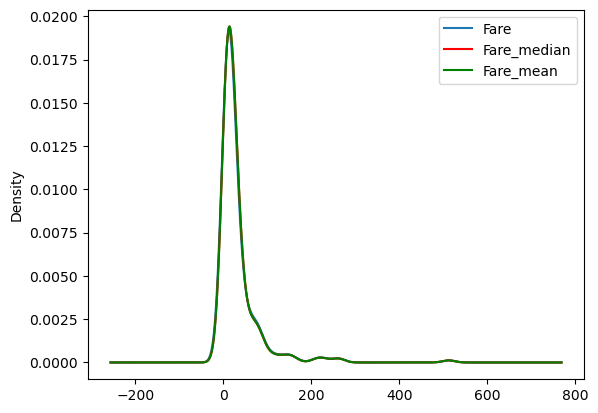

In [99]:
fig=plt.figure()
ax=fig.add_subplot(111)

#original variable distribution
X_train['Fare'].plot(kind='kde',ax=ax)
#variable imputed with the median
X_train['Fare_median'].plot(kind='kde',ax=ax,color='red')
#variable imputed with the median
X_train['Fare_mean'].plot(kind='kde',ax=ax,color='green')

#legends
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')


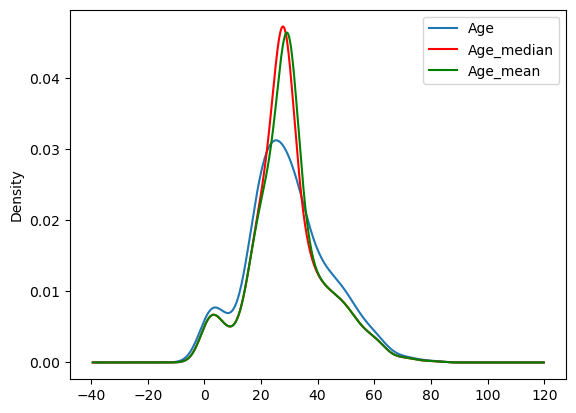

In [100]:
fig=plt.figure()
ax=fig.add_subplot(111)

#original variable distribution
X_train['Age'].plot(kind='kde',ax=ax)
#variable imputed with the median
X_train['Age_median'].plot(kind='kde',ax=ax,color='red')
#variable imputed with the median
X_train['Age_mean'].plot(kind='kde',ax=ax,color='green')

#legends
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [101]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.977921,70.977921
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.660268,17.660268
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,60.511928,60.511928
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.001959,57.001959
Fare_median,70.977921,2761.031435,17.660268,60.511928,57.001959,2621.827268,2621.827268
Fare_mean,70.977921,2761.031435,17.660268,60.511928,57.001959,2621.827268,2621.827268


<Axes: >

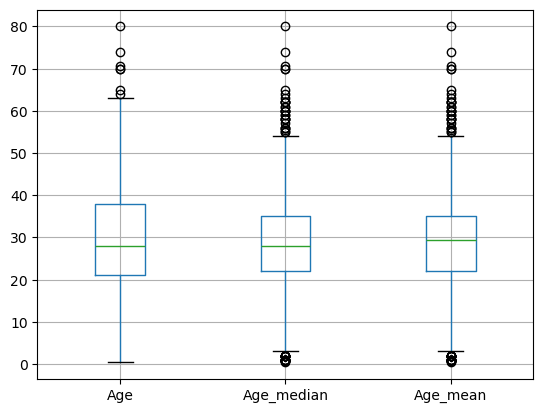

In [102]:
X_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

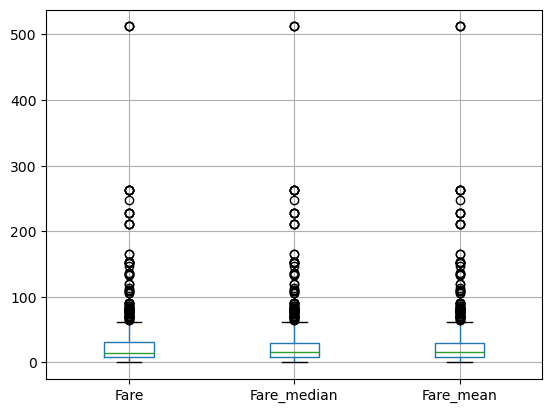

In [103]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

# Using sklearn

In [104]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [105]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [106]:
trf=ColumnTransformer(
    [
        ('Age_Imputer',imputer1,['Age']),
        ('Fare_Imputer',imputer2,['Fare'])
    ],remainder='passthrough',force_int_remainder_cols=False
)

In [107]:
trf.fit(X_train)

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('Age_Imputer',
                                 SimpleImputer(strategy='median'), ['Age']),
                                ('Fare_Imputer', SimpleImputer(), ['Fare'])])

In [108]:
trf.named_transformers_['Age_Imputer'].statistics_

array([28.75])

In [109]:
trf.named_transformers_['Fare_Imputer'].statistics_

array([32.61759689])

In [110]:
X_train = trf.fit_transform(X_train)

X_test = trf.transform(X_test)

In [112]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [113]:
type(X_train)

pandas.core.frame.DataFrame

<Axes: >

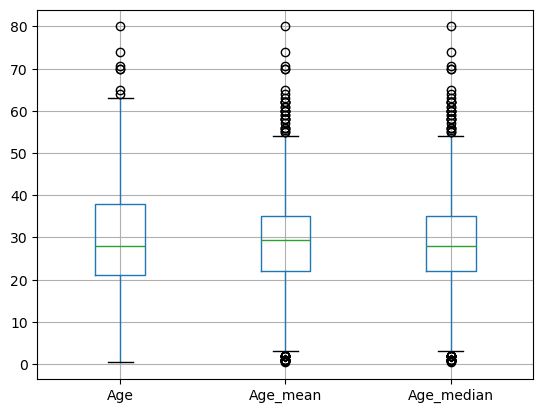

In [117]:
X_train['Age_median']=X_train['Age'].fillna(median_age)
X_train['Age_mean']=X_train['Age'].fillna(mean_age)

X_train['Fare_median']=X_train['Fare'].fillna(median_fare)
X_train['Fare_mean']=X_train['Fare'].fillna(median_fare)

X_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

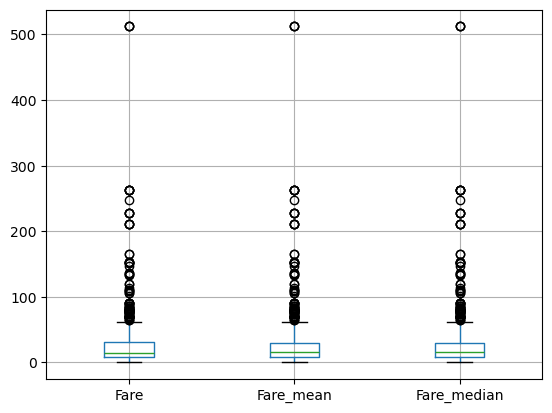

In [118]:
X_train[['Fare','Fare_mean','Fare_median']].boxplot()